<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


/tmp/ipykernel_475/4252061517.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_counts.values, y=industry_counts.index, palette='viridis')

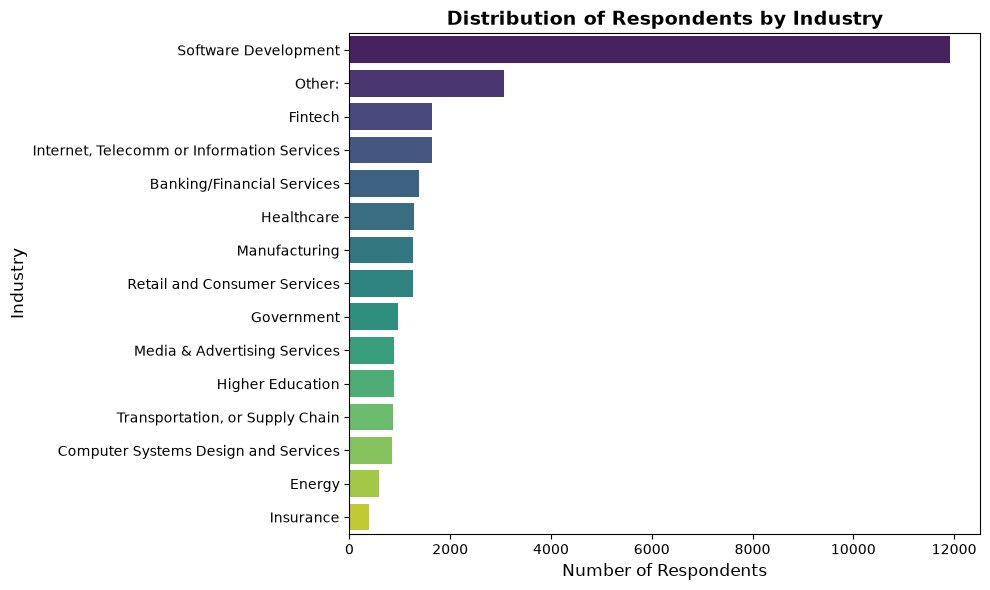

In [3]:
# Count the frequency of each industry and sort them in descending order
industry_counts = df['Industry'].value_counts()

# Set up the plotting environment
plt.figure(figsize=(10, 6))
sns.barplot(x=industry_counts.values, y=industry_counts.index, palette='viridis')

# Add titles and labels for visual clarity
plt.title('Distribution of Respondents by Industry', fontsize=14, fontweight='bold')
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Industry', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [4]:
# Calculate basic statistics
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print(f"Mean Compensation: ${mean_comp:,.2f}")
print(f"Median Compensation: ${median_comp:,.2f}")
print(f"Standard Deviation: ${std_comp:,.2f}")


Mean Compensation: $86,155.29
Median Compensation: $65,000.00
Standard Deviation: $186,756.97

In [5]:
# Define threshold (3 standard deviations above the mean)
upper_threshold = mean_comp + (3 * std_comp)

print(f"High Compensation Outlier Threshold (Mean + 3*STD): ${upper_threshold:,.2f}")


High Compensation Outlier Threshold (Mean + 3*STD): $646,426.21

In [6]:
# Identify respondents exceeding the threshold
high_outliers = df[df['ConvertedCompYearly'] > upper_threshold]

print(f"Number of high compensation outliers: {len(high_outliers)}")

# View the top 5 highest compensation outliers
high_outliers[['Industry', 'ConvertedCompYearly']].sort_values(by='ConvertedCompYearly', ascending=False).head()


Number of high compensation outliers: 89

,Industry,ConvertedCompYearly
15837,NaN,16256603.0
12723,Media & Advertising Services,13818022.0
28379,Computer Systems Design and Services,9000000.0
17593,Software Development,6340564.0
17672,Software Development,4936778.0


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [9]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

# Compute the Interquartile Range (IQR)
IQR = Q3 - Q1

# Determine the structural bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): ${Q1:,.2f}")
print(f"Q3 (75th percentile): ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")
print(f"Lower Bound (for outliers): ${lower_bound:,.2f}")
print(f"Upper Bound (for outliers): ${upper_bound:,.2f}")


Q1 (25th percentile): $32,712.00
Q3 (75th percentile): $107,971.50
IQR: $75,259.50
Lower Bound (for outliers): $-80,177.25
Upper Bound (for outliers): $220,860.75

In [10]:
# Count respondents falling outside the IQR bounds
iqr_outliers = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]

print(f"Total number of outliers using IQR method: {len(iqr_outliers)}")


Total number of outliers using IQR method: 978

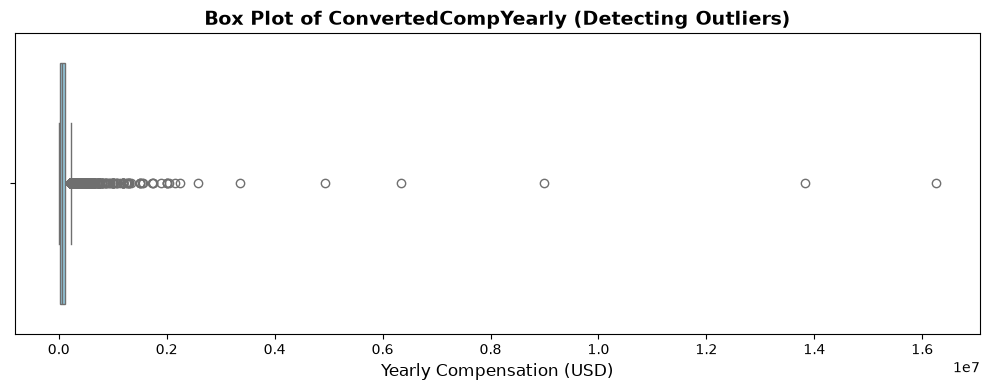

In [11]:
plt.figure(figsize=(10, 4))

# Create a horizontal boxplot
sns.boxplot(x=df['ConvertedCompYearly'], color='skyblue')

# Add titles and labels for scannability
plt.title('Box Plot of ConvertedCompYearly (Detecting Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Yearly Compensation (USD)', fontsize=12)

plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [13]:
# Create a new DataFrame excluding outlier rows
df_clean = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]



In [14]:
# Print structural shapes to validate the data reduction
print("--- DataFrame Size Validation ---")
print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape:  {df_clean.shape}")

# Calculate the exact number of rows removed
rows_removed = df.shape[0] - df_clean.shape[0]
print(f"Total outlier rows removed: {rows_removed}")


--- DataFrame Size Validation ---
Original DataFrame shape: (65437, 114)
Cleaned DataFrame shape:  (22457, 114)
Total outlier rows removed: 42980

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [15]:
# Check unique values in Age to verify mapping requirements
print(df['Age'].unique())

# Define the mapping dictionary based on the dataset intervals
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 68
}

# Create the transformed numerical column
df['Age_numeric'] = df['Age'].map(age_mapping)


<ArrowStringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  'Prefer not to say',  '65 years or older']
Length: 8, dtype: str

In [16]:
# Select numeric columns relevant for correlation analysis
numeric_cols = ['Age_numeric', 'ConvertedCompYearly', 'WorkExp', 'YearsCode']

# Ensure columns are numeric data types, dropping rows with missing values for the calculation
correlation_matrix = df[numeric_cols].apply(pd.to_numeric, errors='coerce').corr()

print(correlation_matrix)


                     Age_numeric  ConvertedCompYearly   WorkExp  YearsCode
Age_numeric             1.000000             0.121782  0.850354   0.799726
ConvertedCompYearly     0.121782             1.000000  0.154114   0.138916
WorkExp                 0.850354             0.154114  1.000000   0.865978
YearsCode               0.799726             0.138916  0.865978   1.000000

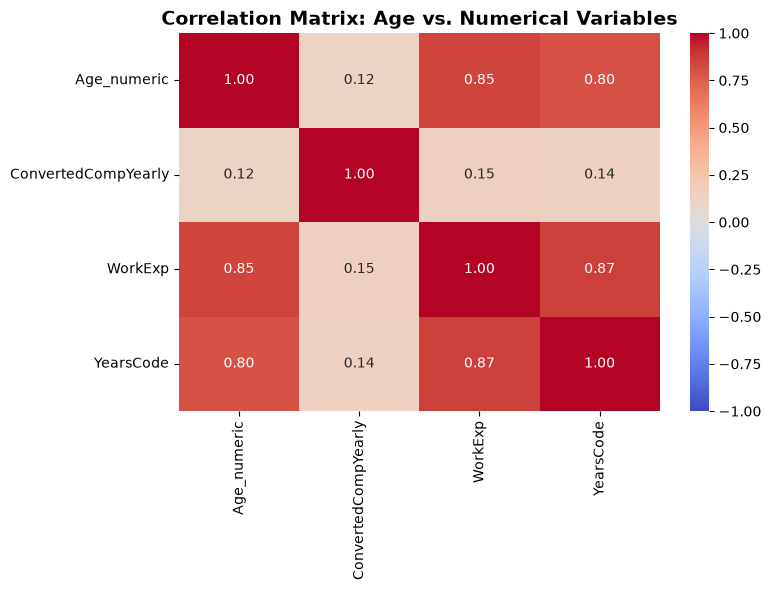

In [17]:
plt.figure(figsize=(8, 6))

# Plot the heatmap
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show exact correlation values in cells
    cmap='coolwarm',     # Red for positive, blue for negative correlation
    fmt=".2f",           # Round to two decimal places
    vmin=-1, vmax=1      # Set bounds of the correlation spectrum
)

plt.title('Correlation Matrix: Age vs. Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
